In [ ]:
# Настройка путей 
import sys
from pathlib import Path

# Получаем путь к корню проекта: поднимаемся из "Jupyter Notebooks/" на уровень выше
project_root = Path().resolve().parent

# Добавляем корень проекта в sys.path
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print(f"Project root added to sys.path: {project_root}")

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from datetime import datetime
from config import RAW_DATA_DIR
from src.db.queries import run_query

# Загрузка данных
df = pd.read_csv(RAW_DATA_DIR / "third_wave_coffee_shop.csv", parse_dates=['datetime', 'sale_date'])


**Цель — трехступенчатый процесс:**

`Шаг 1:` Найти уникальные чеки и их стоимость. Нужно получить таблицу, где каждая строка - это один уникальный чек (**transaction_id**) и его сумма (**total_cost**).

`Шаг 2:` Сложить стоимость этих уникальных чеков по дням. Нужно взять результат` Шага 1` и сгруппировать его по дате, чтобы получить правильную дневную выручку (daily_revenue).

`Шаг 3:` Применить оконную функцию. Нужно взять результат `Шага 2` и посчитать для него скользящее среднее.

In [3]:
# Run query 

from src.db.queries import run_query

query = '''
-- Используем CTE для пошагового построения логики
WITH
-- Шаг 1: Находим уникальные транзакции (чеки) и их стоимость.
-- Это решает проблему дублирования total_cost.
unique_transactions AS (
    SELECT
        sale_date::DATE AS sale_date,
        transaction_id,
        MAX(total_cost) AS transaction_revenue
    FROM public.third_wave_coffee_shop
    GROUP BY sale_date::DATE, transaction_id
),

-- Шаг 2: Агрегируем выручку по дням, используя уникальные чеки с Шага 1.
-- Получаем дневную выручку.
daily_agg AS (
    SELECT
        sale_date,
        SUM(transaction_revenue) AS daily_revenue
    FROM unique_transactions
    GROUP BY sale_date
)
-- Шаг 3: Применяем оконную функцию к результату Шага 2.
SELECT
    sale_date AS __timestamp__, -- Для Superset
    daily_revenue,
    AVG(daily_revenue) OVER (
        ORDER BY sale_date
        ROWS BETWEEN 6 PRECEDING AND CURRENT ROW
    ) AS rolling_mean_7d
FROM daily_agg
ORDER BY __timestamp__;
'''
df = run_query(query)
df


2025-12-29 09:44:49.606 | INFO     | src.db.queries:run_query:28 - Query returned 92 rows


,__timestamp__,daily_revenue,rolling_mean_7d
0,2025-07-01,18640.0,18640.000000
1,2025-07-02,17430.0,18035.000000
2,2025-07-03,25150.0,20406.666667
3,2025-07-04,18410.0,19907.500000
4,2025-07-05,18330.0,19592.000000
...,...,...,...
87,2025-09-26,21030.0,17737.142857
88,2025-09-27,19740.0,18121.428571
89,2025-09-28,16470.0,18627.142857
90,2025-09-29,17960.0,18598.571429


In [6]:
print(df.columns.tolist())

['__timestamp__', 'daily_revenue', 'rolling_mean_7d']


In [ ]:
# Unique transactions
unique_transactions = (
    df.groupby(["sale_date", "transaction_id"], as_index=False)
        .agg(transaction_revenue=("total_cost", "max"))
)

# Daily aggregation
daily_agg = (
    unique_transactions.groupby("sale_date", as_index=False)
    .agg(daily_revenue=("transaction_revenue", "sum"))
)

# Rolling mean
daily_agg["rolling_mean_7d"] = (
    daily_agg["daily_revenue"]
    .rolling(window=7, min_periods=1)
    .mean()
)


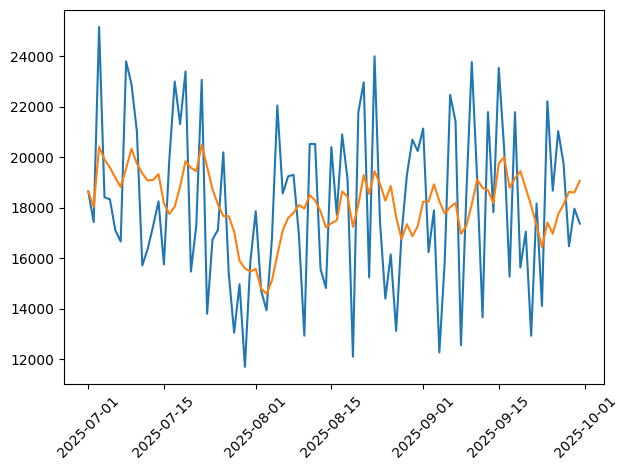

,sale_date,daily_revenue,rolling_mean_7d
0,2025-07-01,18640.0,18640.000000
1,2025-07-02,17430.0,18035.000000
2,2025-07-03,25150.0,20406.666667
3,2025-07-04,18410.0,19907.500000
4,2025-07-05,18330.0,19592.000000


In [5]:
# Plot
plt.figure()
plt.plot(daily_agg["sale_date"], daily_agg["daily_revenue"])
plt.plot(daily_agg["sale_date"], daily_agg["rolling_mean_7d"])
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

daily_agg.head()